In [6]:
# ── CELDA 1: Importaciones ─────────────────────────────────

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scripts.database import engine

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120})

print("✅ Librerías cargadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías cargadas correctamente
   pandas      2.2.2
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [7]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    pais,
    pais_code,
    anio,
    indicador,
    indicador_code,
    valor,
    fecha_extraccion
FROM worldbank_registros
ORDER BY pais, anio, indicador, fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 1,803
   Columnas : 7

📋 Primeras filas:


,pais,pais_code,anio,indicador,indicador_code,valor,fecha_extraccion
0,Argentina,AR,1960,GDP (current US$),NY.GDP.MKTP.CD,1.586547e+10,2026-03-26 20:21:31.472958+00:00
1,Argentina,AR,1960,"Population, total",SP.POP.TOTL,2.038604e+07,2026-03-26 20:22:20.270025+00:00
2,Argentina,AR,1961,GDP (current US$),NY.GDP.MKTP.CD,2.013222e+10,2026-03-26 20:21:30.883671+00:00
3,Argentina,AR,1961,"Population, total",SP.POP.TOTL,2.072628e+07,2026-03-26 20:22:19.703936+00:00
4,Argentina,AR,1962,GDP (current US$),NY.GDP.MKTP.CD,1.833769e+10,2026-03-26 20:21:30.237574+00:00


In [8]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n🌍 Países en el dataset:")
print(df['pais'].value_counts())
print(f"\n📌 Indicadores en el dataset:")
print(df['indicador'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1803 entries, 0 to 1802
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   pais              1803 non-null   object             
 1   pais_code         1803 non-null   object             
 2   anio              1803 non-null   int64              
 3   indicador         1803 non-null   object             
 4   indicador_code    1803 non-null   object             
 5   valor             1803 non-null   float64            
 6   fecha_extraccion  1803 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(4)
memory usage: 98.7+ KB
None

📊 Valores nulos por columna:
pais                0
pais_code           0
anio                0
indicador           0
indicador_code      0
valor               0
fecha_extraccion    0
dtype: int64

🌍 Países en el dataset:
pais
Colombia  

In [9]:
# ── CELDA 4: Limpieza y deduplicación ────────────────────────
df["anio"] = df["anio"].astype(int)
df["fecha_extraccion"] = pd.to_datetime(df["fecha_extraccion"], errors="coerce")

# Mantener el registro más reciente por país-año-indicador
df = df.sort_values(
    ["pais", "anio", "indicador", "fecha_extraccion"],
    ascending=[True, True, True, False]
)

df = df.drop_duplicates(
    subset=["pais_code", "anio", "indicador_code"],
    keep="first"
).reset_index(drop=True)

print(f"✅ Registros después de deduplicar: {len(df):,}")
df.head()

✅ Registros después de deduplicar: 1,803


,pais,pais_code,anio,indicador,indicador_code,valor,fecha_extraccion
0,Argentina,AR,1960,GDP (current US$),NY.GDP.MKTP.CD,1.586547e+10,2026-03-26 20:21:31.472958+00:00
1,Argentina,AR,1960,"Population, total",SP.POP.TOTL,2.038604e+07,2026-03-26 20:22:20.270025+00:00
2,Argentina,AR,1961,GDP (current US$),NY.GDP.MKTP.CD,2.013222e+10,2026-03-26 20:21:30.883671+00:00
3,Argentina,AR,1961,"Population, total",SP.POP.TOTL,2.072628e+07,2026-03-26 20:22:19.703936+00:00
4,Argentina,AR,1962,GDP (current US$),NY.GDP.MKTP.CD,1.833769e+10,2026-03-26 20:21:30.237574+00:00


In [13]:
# ── CELDA 5: Detectar indicadores clave ──────────────────────


pib = next((i for i in indicadores if "GDP" in i or "PIB" in i), None)
inflacion = next((i for i in indicadores if "Inflation" in i or "Inflacion" in i), None)
poblacion = next((i for i in indicadores if "Population" in i or "Poblacion" in i), None)

print("PIB detectado       :", pib)
print("Inflación detectada :", inflacion)
print("Población detectada :", poblacion)

PIB detectado       : GDP (current US$)
Inflación detectada : Inflation, consumer prices (annual %)
Población detectada : Population, total


In [14]:
# ── CELDA 6: Tabla pivote ────────────────────────────────────
df_pivot = (
    df[df["indicador"].isin(seleccion)]
    .pivot_table(
        index=["pais", "anio"],
        columns="indicador",
        values="valor",
        aggfunc="first"
    )
    .reset_index()
)

# 🔹 Ordenar datos (mejora para modelos y gráficos)
df_pivot = df_pivot.sort_values(["pais", "anio"])

# 🔹 Verificación rápida
print("📊 Datos pivot creados")
print(f"Filas: {len(df_pivot)}")
print(df_pivot.isnull().sum())

df_pivot.head()

📊 Datos pivot creados
Filas: 650
indicador
pais                                      0
anio                                      0
GDP (current US$)                         0
Inflation, consumer prices (annual %)    90
Population, total                        57
dtype: int64


indicador,pais,anio,GDP (current US$),"Inflation, consumer prices (annual %)","Population, total"
0,Argentina,1960,1.586547e+10,NaN,20386045.0
1,Argentina,1961,2.013222e+10,NaN,20726276.0
2,Argentina,1962,1.833769e+10,NaN,21072538.0
3,Argentina,1963,1.827212e+10,NaN,21421705.0
4,Argentina,1964,2.560525e+10,NaN,21769453.0


In [15]:
# ── CELDA 7: Preparación de datos ───────────────────────────

# Detectar indicadores dinámicamente
indicadores = df["indicador"].unique()

pib = next((i for i in indicadores if "GDP" in i or "PIB" in i), None)
inflacion = next((i for i in indicadores if "Inflation" in i or "Inflacion" in i), None)
poblacion = next((i for i in indicadores if "Population" in i or "Poblacion" in i), None)

# Crear diccionario de rename
rename_map = {}
if pib:
    rename_map[pib] = "pib"
if inflacion:
    rename_map[inflacion] = "inflacion"
if poblacion:
    rename_map[poblacion] = "poblacion"

# Aplicar rename
df_model = df_pivot.rename(columns=rename_map).copy()

# ==========================================================
# 🔥 IMPUTACIÓN (SIN ELIMINAR DATOS Y SIN REPETIR VALORES)
# ==========================================================

if "inflacion" in df_model.columns:
    df_model["inflacion"] = df_model.groupby("pais")["inflacion"].transform(
    lambda x: x.interpolate().bfill().ffill()

    )

if "pib" in df_model.columns:
    df_model["pib"] = df_model.groupby("pais")["pib"].transform(
        lambda x: x.interpolate()
    )

if "poblacion" in df_model.columns:
    df_model["poblacion"] = df_model.groupby("pais")["poblacion"].transform(
        lambda x: x.interpolate().bfill().ffill()
    )

# ==========================================================
# 🔥 LIMPIEZA FINAL (evitar problemas matemáticos)
# ==========================================================

if "inflacion" in df_model.columns:
    df_model["inflacion"] = df_model["inflacion"].clip(lower=0.01)

if "pib" in df_model.columns:
    df_model["pib"] = df_model["pib"].clip(lower=0.01)

if "poblacion" in df_model.columns:
    df_model["poblacion"] = df_model["poblacion"].clip(lower=0.01)

# ==========================================================
# 🔥 VARIABLES LOGARÍTMICAS
# ==========================================================

if "pib" in df_model.columns:
    df_model["log_pib"] = np.log(df_model["pib"])

if "inflacion" in df_model.columns:
    df_model["log_inflacion"] = np.log(df_model["inflacion"])

if "poblacion" in df_model.columns:
    df_model["log_poblacion"] = np.log(df_model["poblacion"])

# ==========================================================
# 🔍 VALIDACIÓN FINAL
# ==========================================================

print("Columnas finales:")
print(df_model.columns)

print("\nValores NaN por columna:")
print(df_model.isnull().sum())

print("\nPrimeras filas:")
df_model.head()

Columnas finales:
Index(['pais', 'anio', 'pib', 'inflacion', 'poblacion', 'log_pib',
       'log_inflacion', 'log_poblacion'],
      dtype='object', name='indicador')

Valores NaN por columna:
indicador
pais             0
anio             0
pib              0
inflacion        0
poblacion        0
log_pib          0
log_inflacion    0
log_poblacion    0
dtype: int64

Primeras filas:


indicador,pais,anio,pib,inflacion,poblacion,log_pib,log_inflacion,log_poblacion
0,Argentina,1960,1.586547e+10,34.277224,20386045.0,23.487411,3.534481,16.830361
1,Argentina,1961,2.013222e+10,34.277224,20726276.0,23.725587,3.534481,16.846913
2,Argentina,1962,1.833769e+10,34.277224,21072538.0,23.632224,3.534481,16.863481
3,Argentina,1963,1.827212e+10,34.277224,21421705.0,23.628642,3.534481,16.879915
4,Argentina,1964,2.560525e+10,34.277224,21769453.0,23.966063,3.534481,16.896018


In [16]:
# ── CELDA 8: Estadísticas descriptivas ───────────────────────
vars_num = [c for c in ["pib", "inflacion", "poblacion", "log_pib", "log_poblacion"] if c in df_model.columns]

desc = df_model[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
indicador           pib  inflacion     poblacion  log_pib  log_poblacion
count      6.500000e+02     650.00  6.500000e+02   650.00         650.00
mean       1.075913e+12      59.46  6.843710e+07    25.04          17.07
std        3.571895e+12     367.50  9.813289e+07     2.33           1.45
min        2.888844e+08       0.01  1.883514e+06    19.48          14.45
25%        1.536590e+10       4.19  9.320600e+06    23.46          16.05
50%        5.941300e+10       9.77  2.437121e+07    24.81          17.01
75%        3.177249e+11      34.28  7.956271e+07    26.48          18.19
max        2.875096e+13    7481.66  3.401110e+08    30.99          19.64


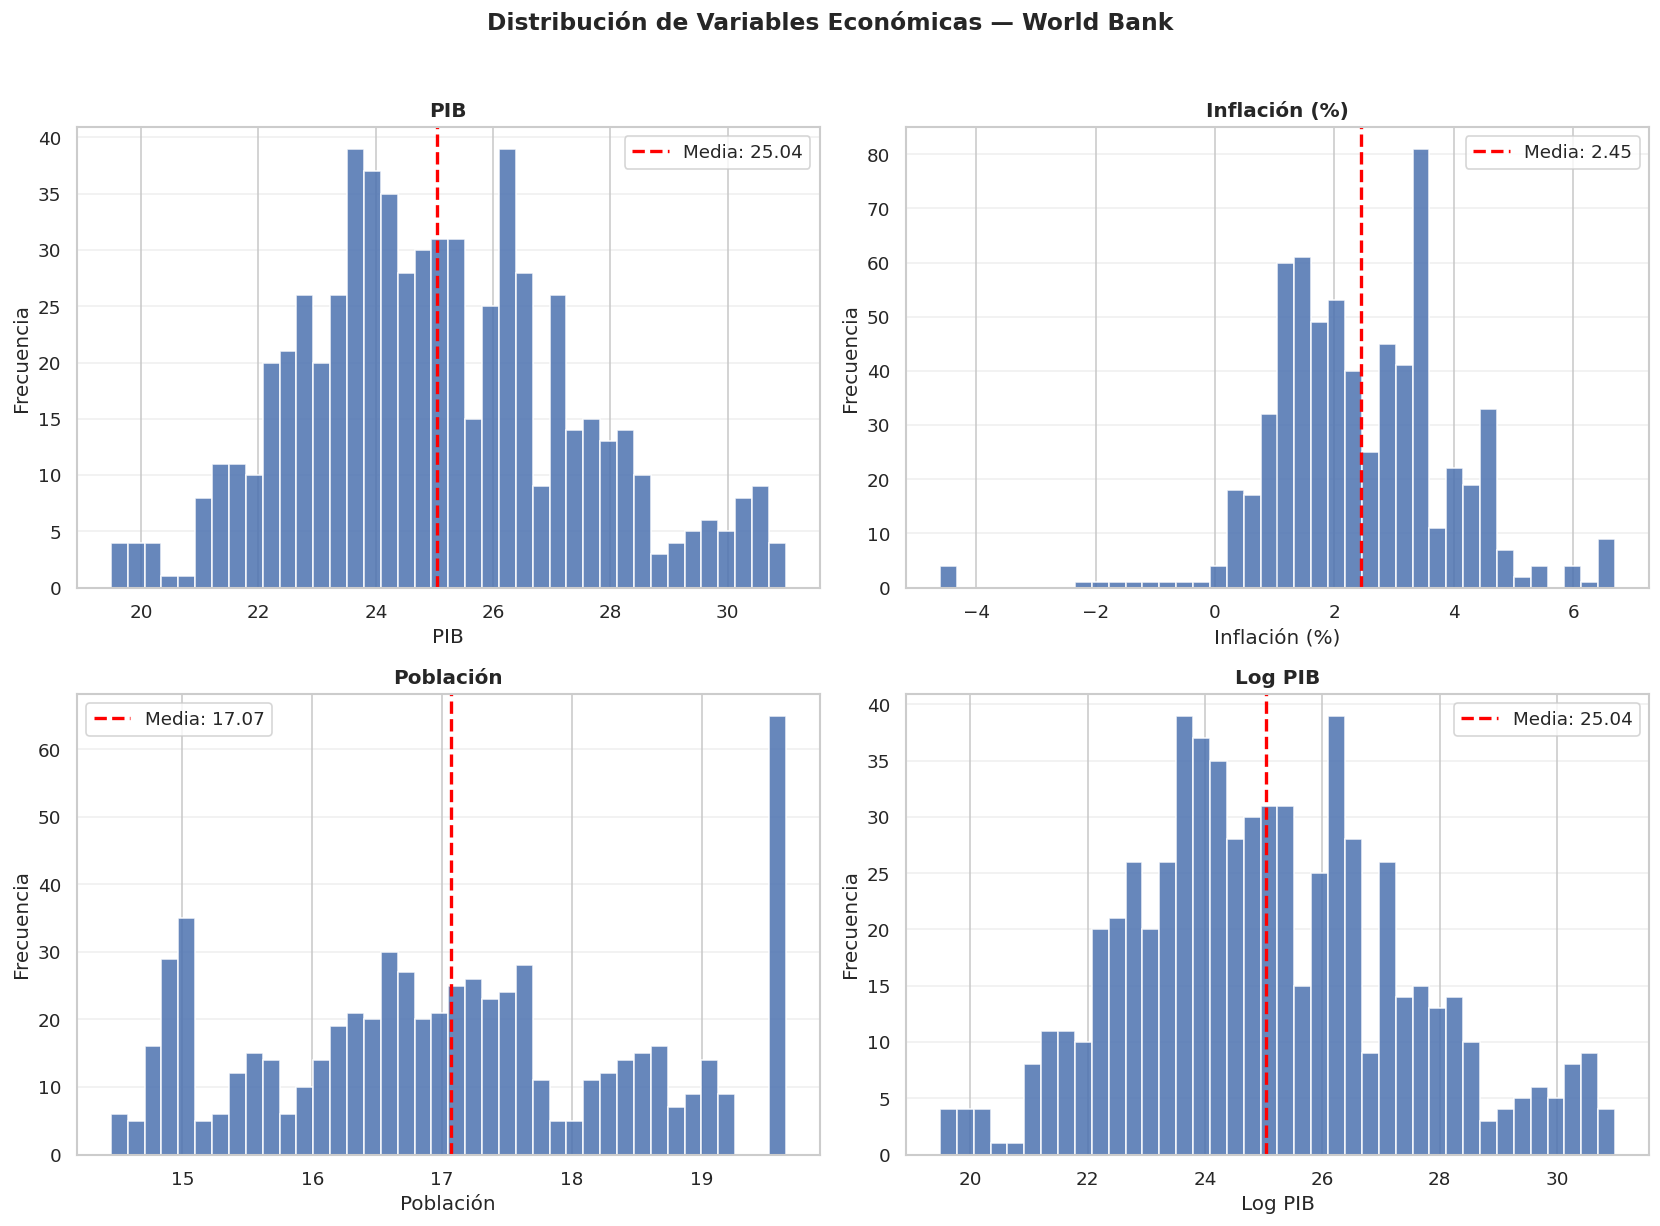

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Económicas — World Bank',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'pib': 'PIB',
    'inflacion': 'Inflación (%)',
    'poblacion': 'Población',
    'log_pib': 'Log PIB',
}

for ax, col in zip(axes.flat, datos.keys()):
    if col in df_model.columns:

        data_col = df_model[col].copy()

        # 🔥 AJUSTES POR VARIABLE (BIEN INDENTADO)
        if col == "inflacion":
            data_col = data_col.fillna(data_col.median())
            data_col = data_col.clip(lower=0.01, upper=data_col.quantile(0.99))
            data_col = np.log(data_col)

        elif col == "pib":
            data_col = data_col.fillna(data_col.median())
            data_col = data_col.clip(lower=0.01)
            data_col = np.log(data_col)

        elif col == "poblacion":
            data_col = data_col.fillna(data_col.median())
            data_col = data_col.clip(lower=0.01)
            data_col = np.log(data_col)

        ax.hist(data_col, bins=40, edgecolor='white', alpha=0.85)

        media = data_col.mean()
        ax.axvline(media, linestyle='--', linewidth=2, color='red',
                   label=f'Media: {media:.2f}')

        ax.set_title(datos[col], fontweight='bold')
        ax.set_xlabel(datos[col])
        ax.set_ylabel('Frecuencia')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones_worldbank.png',
            dpi=150, bbox_inches='tight')

plt.show()

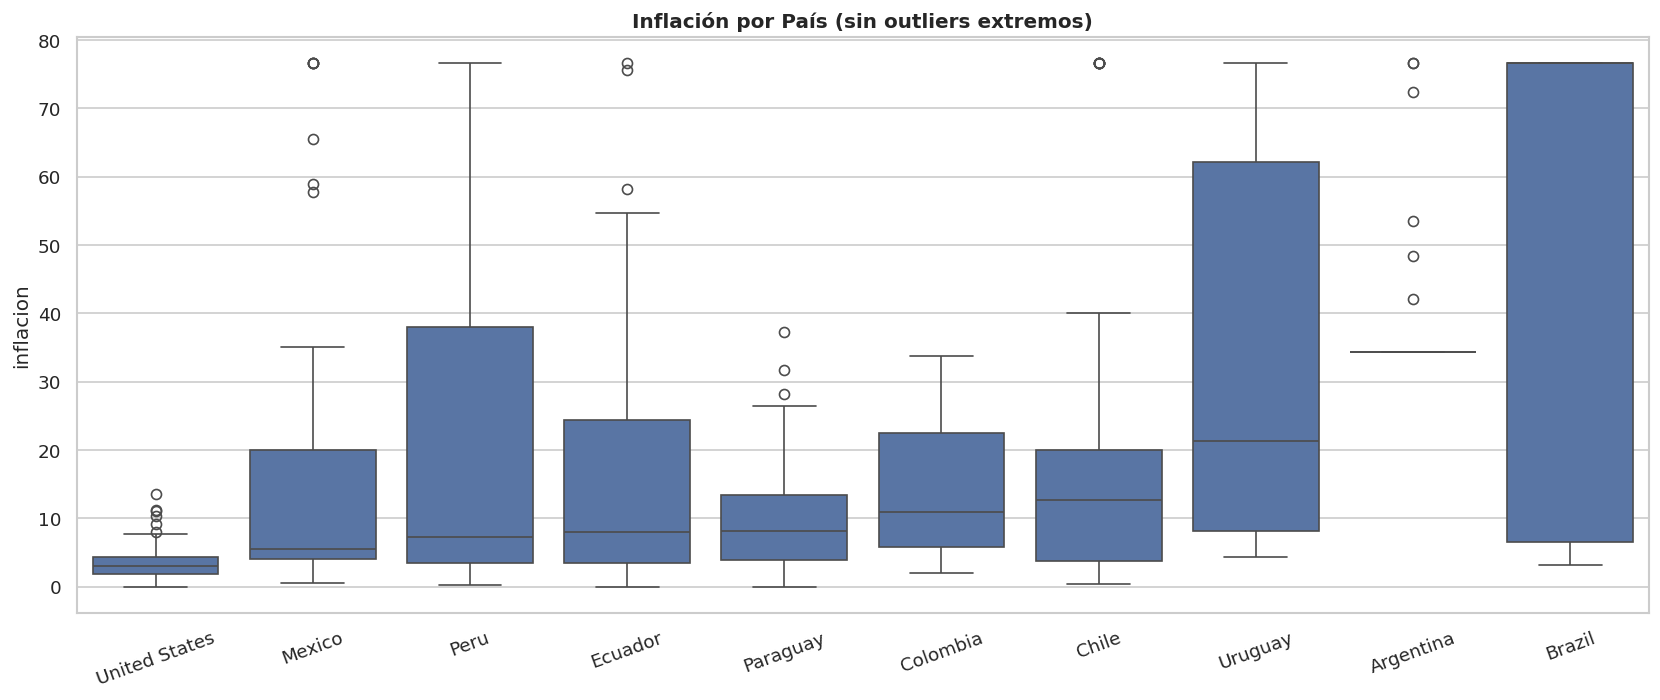

In [18]:
if "inflacion" in df_model.columns:

    df_model = df_model.copy()

    # 🔥 Reemplazar NaN
    df_model["inflacion"] = df_model["inflacion"].fillna(df_model["inflacion"].median())

    # 🔥 Limitar valores extremos (MUY IMPORTANTE)
    upper_limit = df_model["inflacion"].quantile(0.90)
    df_model["inflacion"] = df_model["inflacion"].clip(lower=0.01, upper=upper_limit)

    # 🔥 Log para análisis posterior (no para el boxplot)
    df_model["log_inflacion"] = np.log(df_model["inflacion"])

    plt.figure(figsize=(14, 6))

    orden = df_model.groupby('pais')['inflacion'].median().sort_values().index

    sns.boxplot(data=df_model, x='pais', y='inflacion', order=orden)

    plt.title('Inflación por País (sin outliers extremos)', fontweight='bold')
    plt.xlabel('')
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.savefig('../data/graficas/eda_boxplot_inflacion_pais.png',
                dpi=150, bbox_inches='tight')

    plt.show()

else:
    print("No existe columna inflacion.")

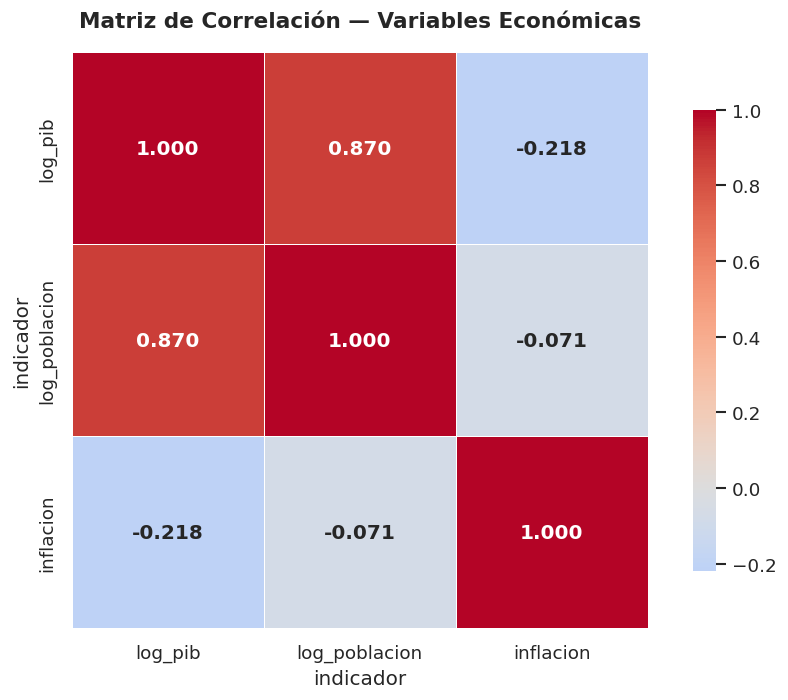

In [19]:
# ── CELDA 11: Matriz de correlación ──────────────────────────
corr_vars = [c for c in ["log_pib", "log_poblacion", "inflacion"] if c in df_model.columns]
corr = df_model[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Económicas',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion_worldbank.png',
            dpi=150, bbox_inches='tight')
plt.show()

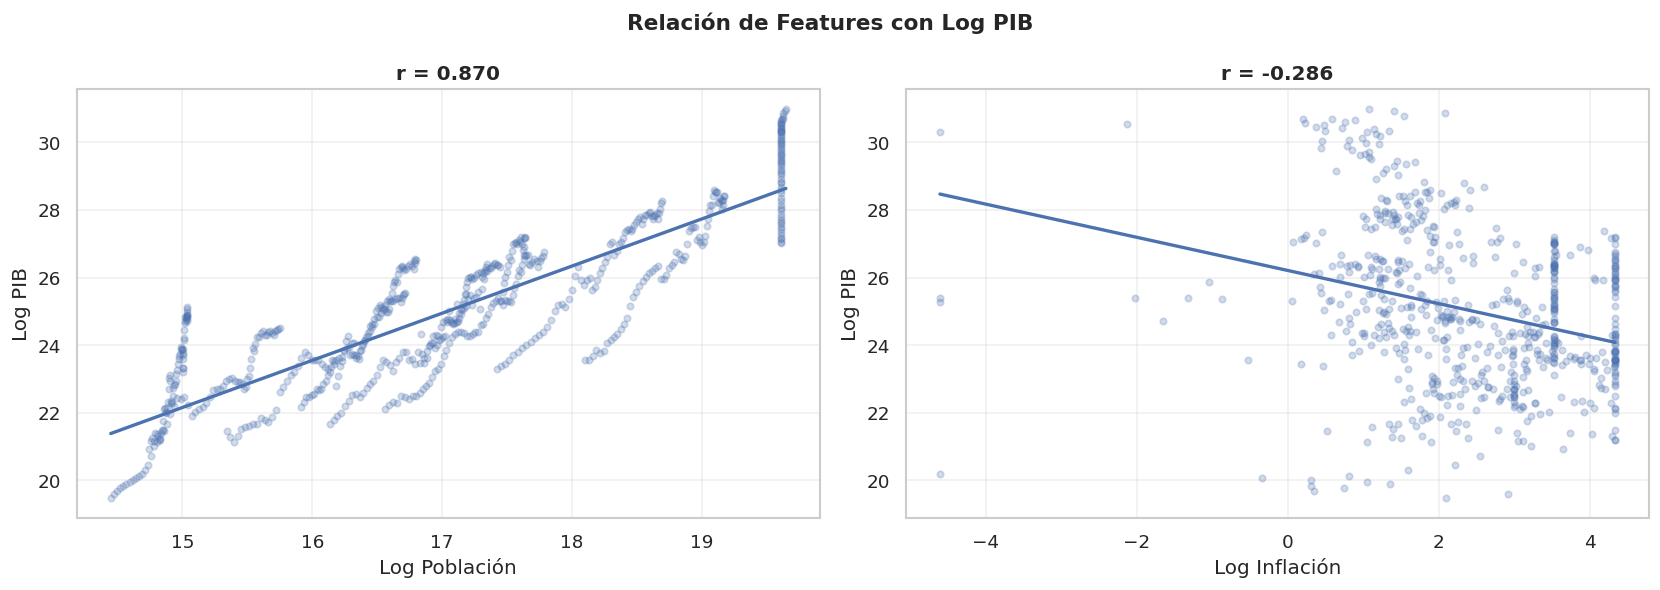

In [20]:
# ── CELDA 12: Scatter plots ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relación de Features con Log PIB',
             fontsize=13, fontweight='bold')

pares = [
    ('log_poblacion', 'Log Población'),
    ('log_inflacion', 'Log Inflación'),   # 🔥 CAMBIO AQUÍ
]

for ax, (feature, xlabel) in zip(axes, pares):

    if feature in df_model.columns and "log_pib" in df_model.columns:

        data = df_model[[feature, "log_pib"]].replace([np.inf, -np.inf], np.nan).copy()

        # 🔥 Reemplazar NaN (NO eliminar)
        data[feature] = data[feature].fillna(data[feature].median())
        data["log_pib"] = data["log_pib"].fillna(data["log_pib"].median())

        if len(data) < 2:
            ax.set_title("Datos insuficientes")
            continue

        x = data[feature].values
        y = data["log_pib"].values

        # Scatter
        ax.scatter(x, y, alpha=0.25, s=15)

        # Línea de regresión
        try:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            xp = np.linspace(x.min(), x.max(), 200)
            ax.plot(xp, p(xp), linewidth=2)
        except:
            pass

        # Correlación
        r = np.corrcoef(x, y)[0, 1]

        ax.set_title(f'r = {r:.3f}', fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Log PIB')
        ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/eda_scatter_worldbank.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [21]:
# ── CELDA 13: Split Train / Test ─────────────────────────────
df_simple = df_model.copy()

df_simple["log_pib"] = df_simple["log_pib"].interpolate()
df_simple["log_poblacion"] = df_simple["log_poblacion"].interpolate()

X_simple = df_simple[['log_poblacion']].values
y = df_simple['log_pib'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 520 muestras (80%)
Test : 130 muestras (20%)


In [22]:
# ── CELDA 14: Entrenamiento con scikit-learn ─────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : log_pib = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × log_poblacion")

Intercepto  β₀ : 0.5069
Coeficiente β₁ : 1.4388

Ecuación : log_pib = 0.507 + 1.439 × log_poblacion


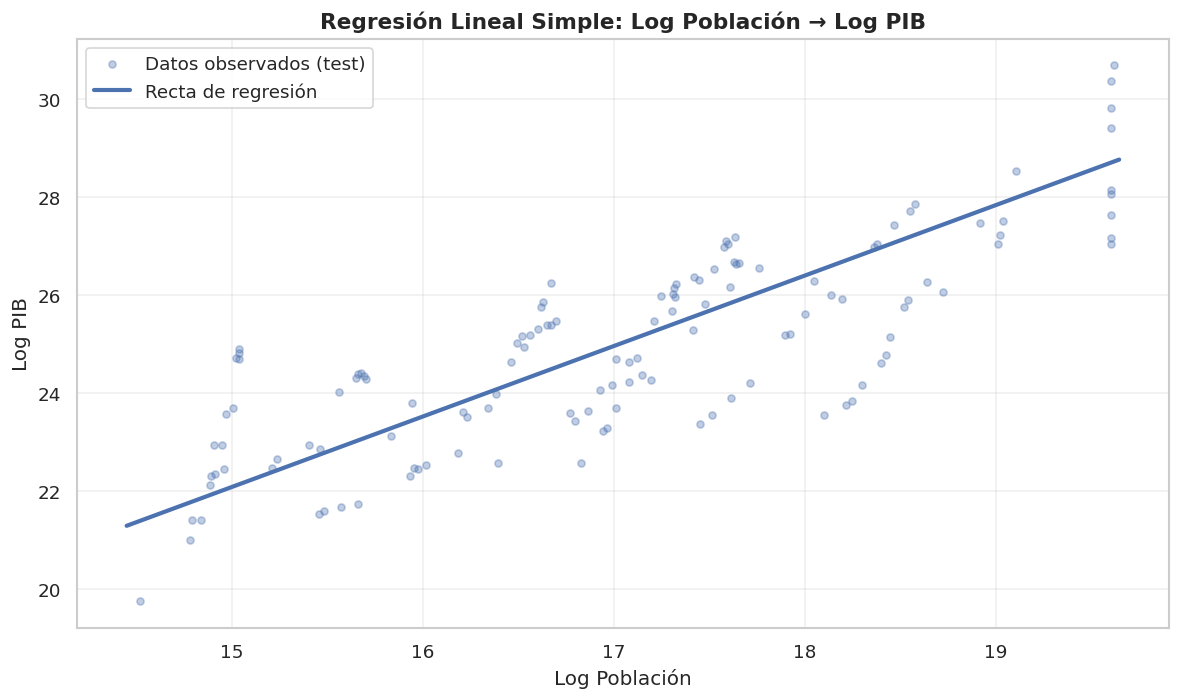

In [23]:
# ── CELDA 15: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18, label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Log Población', fontsize=12)
ax.set_ylabel('Log PIB', fontsize=12)
ax.set_title('Regresión Lineal Simple: Log Población → Log PIB',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple_worldbank.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── CELDA 16: Métricas del modelo simple ─────────────────────
r2 = r2_score(y_test, y_pred_simple)
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   : {r2:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   : 0.6144
  MSE  : 1.5432
  RMSE : 1.2423
  MAE  : 1.0361


In [25]:
# ── CELDA 17: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df_simple['log_poblacion'])
modelo_ols_simple = sm.OLS(df_simple['log_pib'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                log_pib   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     2019.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          2.86e-201
Time:                        20:17:53   Log-Likelihood:                -1011.6
No. Observations:                 650   AIC:                             2027.
Df Residuals:                     648   BIC:                             2036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2405      0.532      2.334

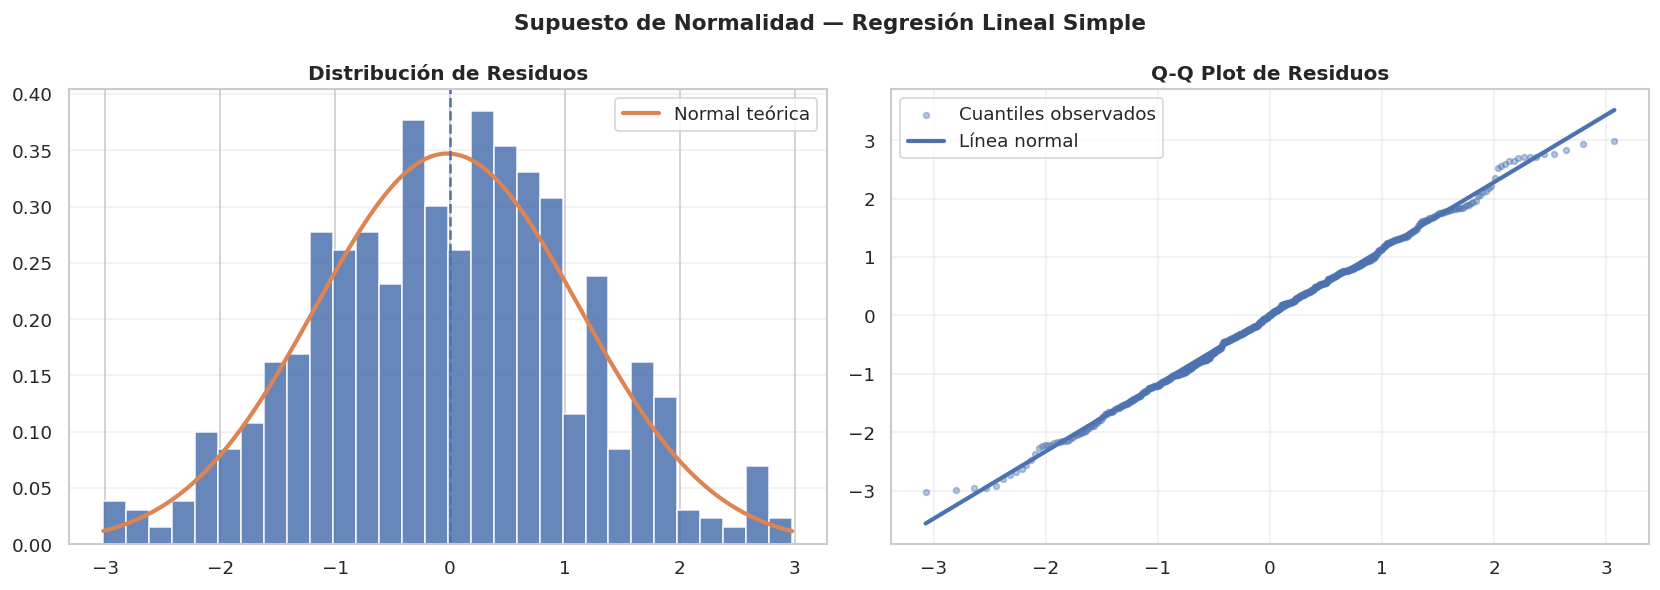

Shapiro-Wilk p-value: 0.194259
✅ No se rechaza normalidad


In [26]:
# ── CELDA 18: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df_simple[['log_poblacion']].values)
residuos = df_simple['log_pib'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=30, density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept, linewidth=2.5, label='Línea normal')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple_worldbank.png',
            dpi=150, bbox_inches='tight')
plt.show()

stat_sw, p_sw = stats.shapiro(residuos if len(residuos) <= 5000 else residuos[:5000])

print(f"Shapiro-Wilk p-value: {p_sw:.6f}")
print("✅ No se rechaza normalidad" if p_sw > 0.05 else "⚠️ Se rechaza normalidad")

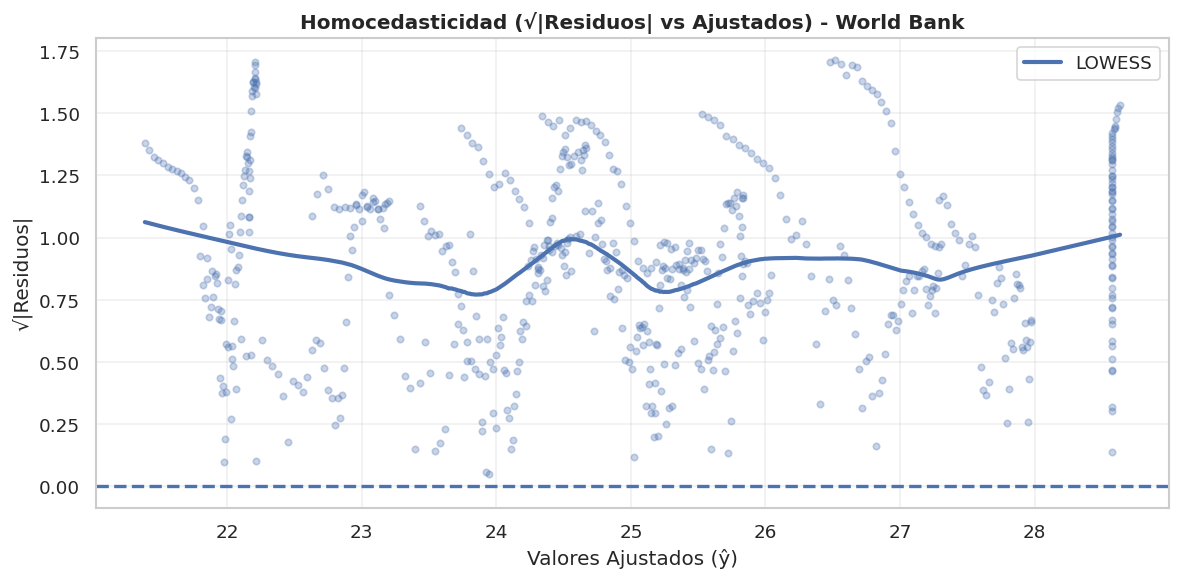

Breusch-Pagan p-value: 0.367260
✅ Homocedasticidad


In [27]:
# ── CELDA 19: Homocedasticidad (modelo simple) ───────────────
import numpy as np

residuos_ols = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

# 🔹 Aplicar raíz cuadrada a la magnitud del residuo
residuos_sqrt = np.sqrt(np.abs(residuos_ols))

plt.figure(figsize=(10, 5))

# Scatter con raíz cuadrada
plt.scatter(ajustados_ols, residuos_sqrt, alpha=0.30, s=15)

plt.axhline(0, linestyle='--', linewidth=2)

# LOWESS con raíz cuadrada
lowess = sm.nonparametric.lowess(residuos_sqrt, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], linewidth=2.5, label='LOWESS')

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('√|Residuos|', fontsize=12)

plt.title('Homocedasticidad (√|Residuos| vs Ajustados) - World Bank',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../data/graficas/homoc_sqrt_worldbank.png',
            dpi=150, bbox_inches='tight')

plt.show()

# Test estadístico (igual que antes)
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)

print(f"Breusch-Pagan p-value: {lm_p:.6f}")
print("✅ Homocedasticidad" if lm_p > 0.05 else "⚠️ Heterocedasticidad detectada")

In [28]:
from sklearn.preprocessing import StandardScaler

# 🔥 Detectar columnas que sí existen
FEATURES = [col for col in ['log_poblacion', 'log_inflacion'] if col in df_model.columns]

if len(FEATURES) == 0:
    raise ValueError("No hay variables disponibles para el modelo")

df_multi = df_model.copy()

# 🔥 Reemplazar NaN sin eliminar datos
for col in FEATURES + ["log_pib"]:
    if col in df_multi.columns:
        df_multi[col] = df_multi[col].interpolate()

# 🔥 Extraer datos
X_multi = df_multi[FEATURES].values
y = df_multi['log_pib'].values

# 🔥 Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

# 🔥 Escalado
scaler_multi = StandardScaler()
X_train_m = scaler_multi.fit_transform(X_train_m)
X_test_m = scaler_multi.transform(X_test_m)

# 🔥 Modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print("Modelo entrenado correctamente ✅")
print("Features usadas:", FEATURES)

Modelo entrenado correctamente ✅
Features usadas: ['log_poblacion', 'log_inflacion']


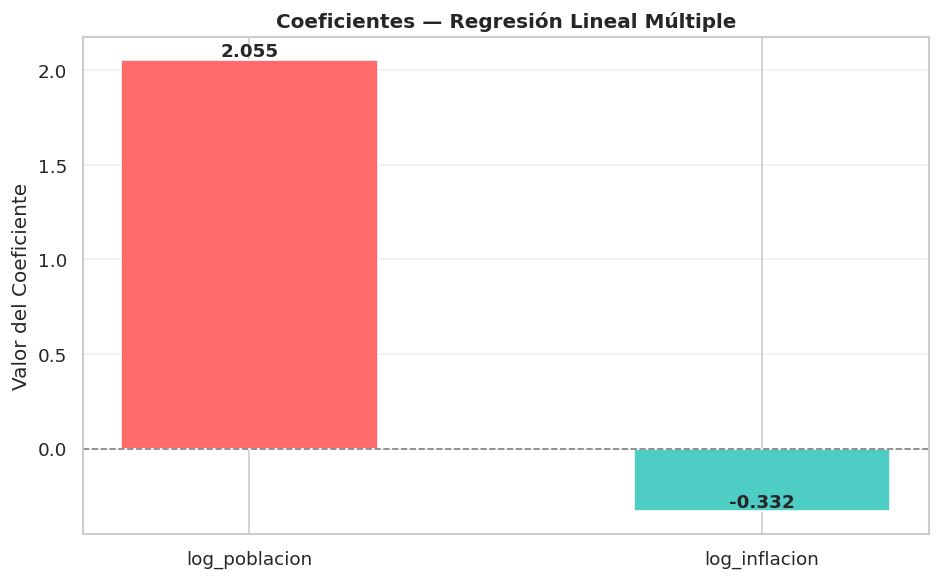

In [29]:
# ── CELDA 21: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_, color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{coef:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi_worldbank.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── CELDA 22: Métricas — modelo múltiple ─────────────────────
r2_m = r2_score(y_test_m, y_pred_multi)
mse_m = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   : {r2_m:.4f}")
print(f"  MSE  : {mse_m:.4f}")
print(f"  RMSE : {rmse_m:.4f}")
print(f"  MAE  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   : 0.6551
  MSE  : 1.3803
  RMSE : 1.1748
  MAE  : 0.9511


In [31]:
# ── CELDA 23: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df_multi[FEATURES])
modelo_ols_multi = sm.OLS(df_multi['log_pib'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                log_pib   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     1137.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.85e-212
Time:                        20:18:03   Log-Likelihood:                -981.72
No. Observations:                 650   AIC:                             1969.
Df Residuals:                     647   BIC:                             1983.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.5059      0.533      4.704

In [32]:
# ── CELDA 24: VIF — Factor de Inflación de la Varianza ───────
X_vif = df_multi[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)

print(vif_data)

        Variable    VIF
0  log_poblacion  3.802
1  log_inflacion  3.802


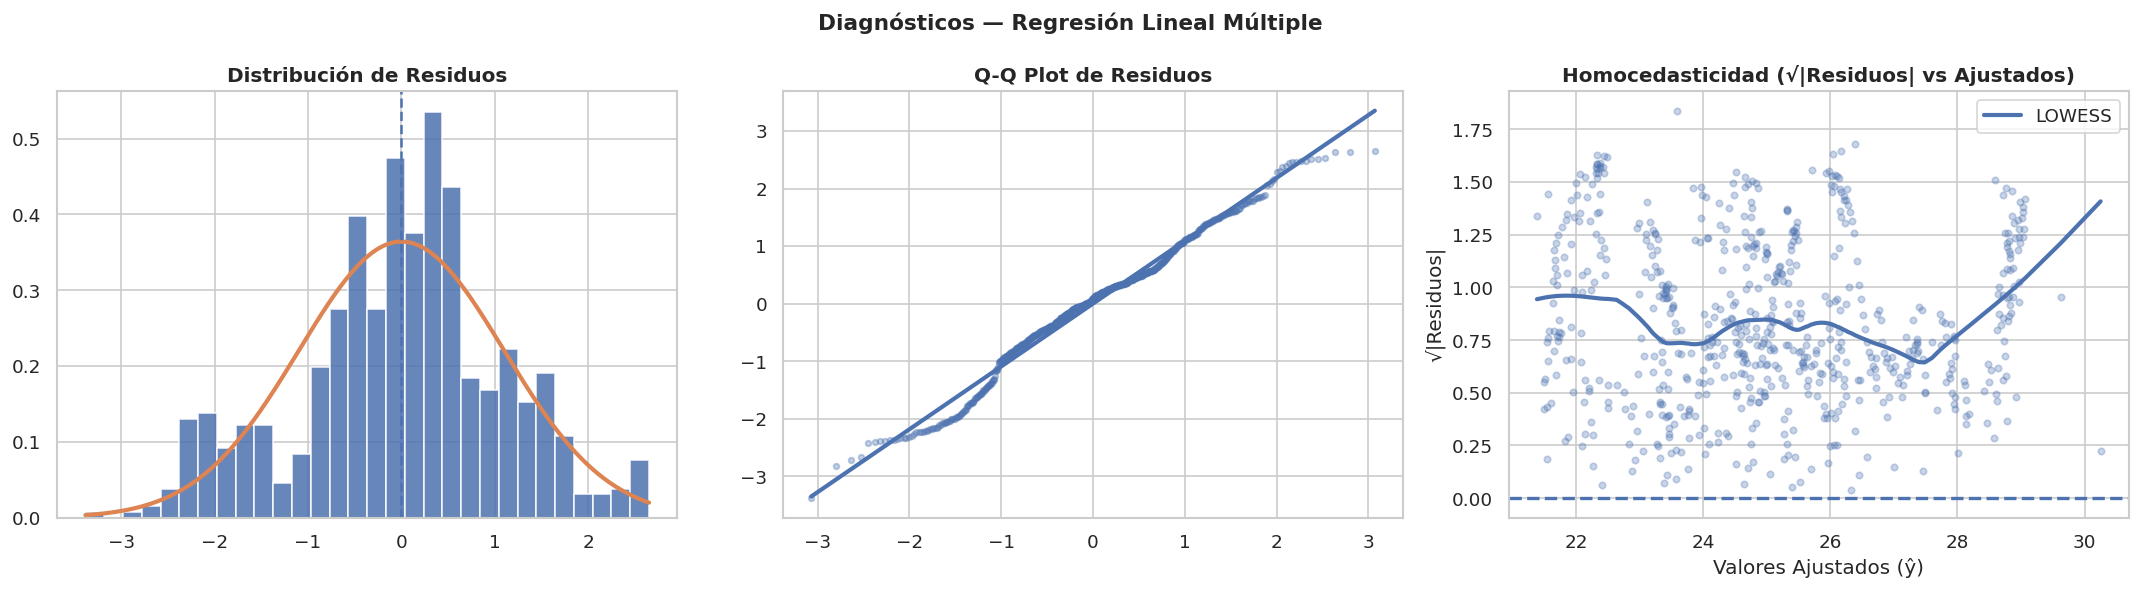

Shapiro-Wilk p-value: 0.000003
Breusch-Pagan p-value: 0.000000


In [33]:
# ── CELDA 25: Diagnósticos completos — modelo múltiple ───────
residuos_m = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos_m, bins=30, density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()), linewidth=2.5)
axes[0].axvline(0, linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')

(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12)
axes[1].plot(osm, s * np.array(osm) + i, linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')

# ── Residuos vs Ajustados (CON RAÍZ CUADRADA)
residuos_sqrt_m = np.sqrt(np.abs(residuos_m))

axes[2].scatter(ajustados_m, residuos_sqrt_m, alpha=0.30, s=15)

axes[2].axhline(0, linestyle='--', linewidth=2)

lowess_m = sm.nonparametric.lowess(residuos_sqrt_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             linewidth=2.5, label='LOWESS')

axes[2].set_title('Homocedasticidad (√|Residuos| vs Ajustados)', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('√|Residuos|')

axes[2].legend()

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi_worldbank.png',
            dpi=150, bbox_inches='tight')
plt.show()

stat_sw_m, p_sw_m = stats.shapiro(residuos_m if len(residuos_m) <= 5000 else residuos_m[:5000])
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid, modelo_ols_multi.model.exog)

print(f"Shapiro-Wilk p-value: {p_sw_m:.6f}")
print(f"Breusch-Pagan p-value: {lm_p_m:.6f}")

In [34]:
# ── CELDA 26: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['log_poblacion', 'log_poblacion + inflacion'],
    'R²': [round(r2, 4), round(r2_m, 4)],
    'R² Aj.': [round(modelo_ols_simple.rsquared_adj, 4),
               round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE': [round(rmse, 4), round(rmse_m, 4)],
    'MAE': [round(mae, 4), round(mae_m, 4)],
    'AIC': [round(modelo_ols_simple.aic, 2), round(modelo_ols_multi.aic, 2)],
    'BIC': [round(modelo_ols_simple.bic, 2), round(modelo_ols_multi.bic, 2)],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)

              COMPARACIÓN DE MODELOS
            Modelo                 Variables     R²  R² Aj.   RMSE    MAE     AIC     BIC
  Regresión Simple             log_poblacion 0.6144  0.7567 1.2423 1.0361 2027.29 2036.25
Regresión Múltiple log_poblacion + inflacion 0.6551  0.7778 1.1748 0.9511 1969.43 1982.86


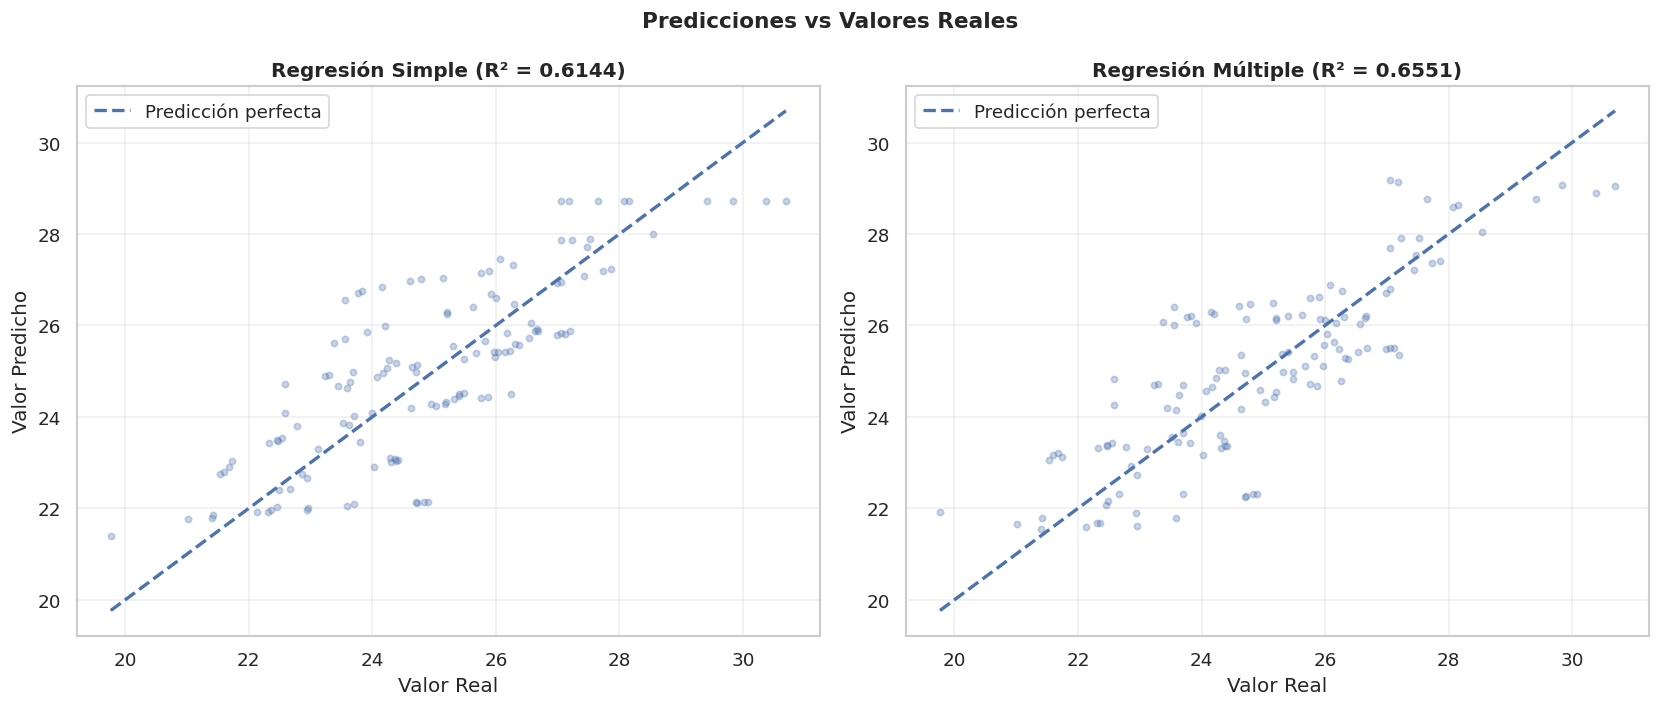

In [35]:
# ── CELDA 27: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test, y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi, 'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14)
    ax.plot([minval, maxval], [minval, maxval],
            linewidth=2, linestyle='--', label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Predicho')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales_worldbank.png',
            dpi=150, bbox_inches='tight')
plt.show()